In [28]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [29]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [30]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 6000
alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

In [31]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))

episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [32]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

for episode in range(num_episodes):

    state, info = env.reset()
    total_reward = 0

    done = False

    while not done:

        # Choose action using epsilon-greedy
        action = choose_action(state, epsilon)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Q-Learning update
        if done:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] = Q[state, action] + alpha * (
            target - Q[state, action]
        )

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [33]:
# -------------------------------------------------
# Extract Value Function and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)

In [34]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [35]:

# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.885 0.951 0.618 0.912]
 [0.844 0.    0.    0.041]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.867 0.961 0.    0.888]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.886 0.    0.97  0.864]
 [0.922 0.98  0.858 0.   ]
 [0.967 0.099 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.95  0.99  0.872]
 [0.957 0.953 1.    0.861]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.951 0.844 0.    0.   ]
 [0.961 0.    0.    0.   ]
 [0.97  0.98  0.967 0.   ]
 [0.    0.99  1.    0.   ]]

Learned Policy:
[['D' 'L' 'L' 'L']
 ['D' 'L' 'L' 'L']
 ['R' 'D' 'L' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.986


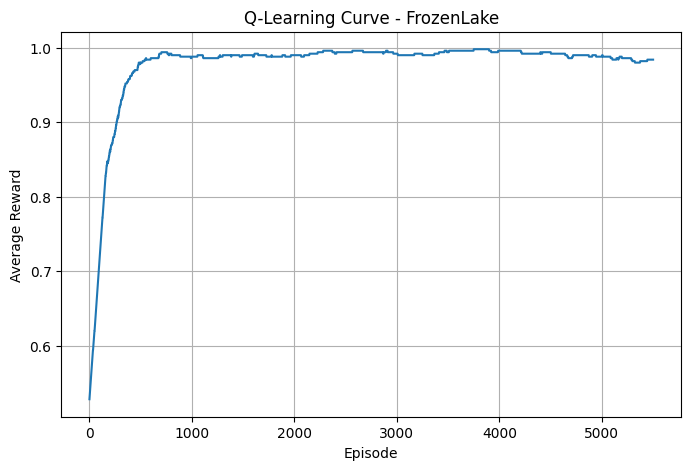

In [36]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()